# Week 2: Exploratory Data Analysis (EDA) & Statistical Testing

In this week, we focus on understanding the relationships within the hotel booking dataset, specifically focusing on cancellations and the drivers behind them. We will:
1. Visualize data distributions.
2. Build a correlation matrix to identify key cancellation drivers.
3. Analyze the relationship between ADR (Average Daily Rate) and cancellation rates.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting aesthetic style for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [5]:
# Load the cleaned dataset from Week 1
df = pd.read_csv('../WEEK1/cleaned_data.csv')
df.head()

,iscanceled,leadtime,arrivaldateyear,arrivaldatemonth,arrivaldateweeknumber,arrivaldatedayofmonth,staysinweekendnights,staysinweeknights,adults,children,...,totalofspecialrequests,reservationstatus,reservationstatusdate,totalstay,res_year,res_month,res_day,res_weekday,pricepernight,adr_log
0,0,342,2015,July,27,1,0,0,2,0,...,0,Check-Out,2015-07-01,0,2015,7,1,2,0.0,0.000000
1,0,737,2015,July,27,1,0,0,2,0,...,0,Check-Out,2015-07-01,0,2015,7,1,2,0.0,0.000000
2,0,7,2015,July,27,1,0,1,1,0,...,0,Check-Out,2015-07-02,1,2015,7,2,3,75.0,4.330733
3,0,13,2015,July,27,1,0,1,1,0,...,0,Check-Out,2015-07-02,1,2015,7,2,3,75.0,4.330733
4,0,14,2015,July,27,1,0,2,2,0,...,1,Check-Out,2015-07-03,2,2015,7,3,4,98.0,4.595120


## 1. Visualizing Data Distributions

Understanding the distribution of key variables like `leadtime`, `totalstay`, and `adr`.

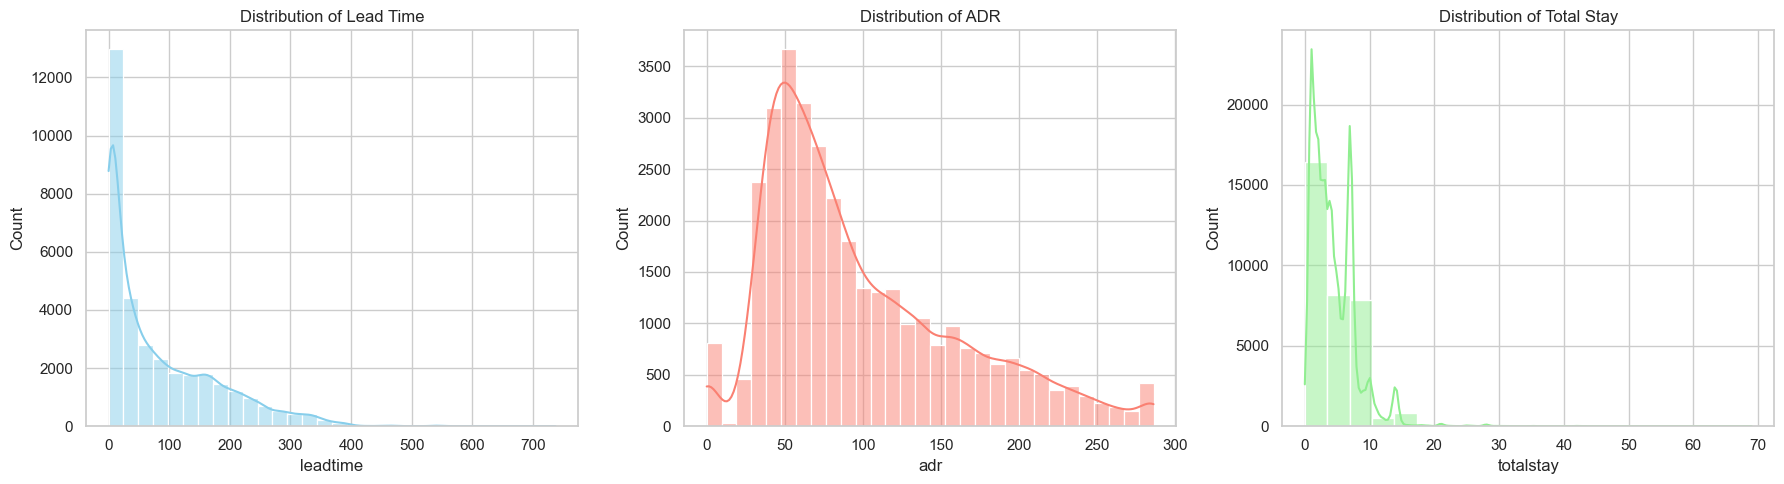

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['leadtime'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Lead Time')

sns.histplot(df['adr'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of ADR')

sns.histplot(df['totalstay'], bins=20, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Total Stay')

plt.tight_layout()
plt.show()

## 2. Correlation Matrix

Identifying variables that are strongly correlated with `iscanceled`.

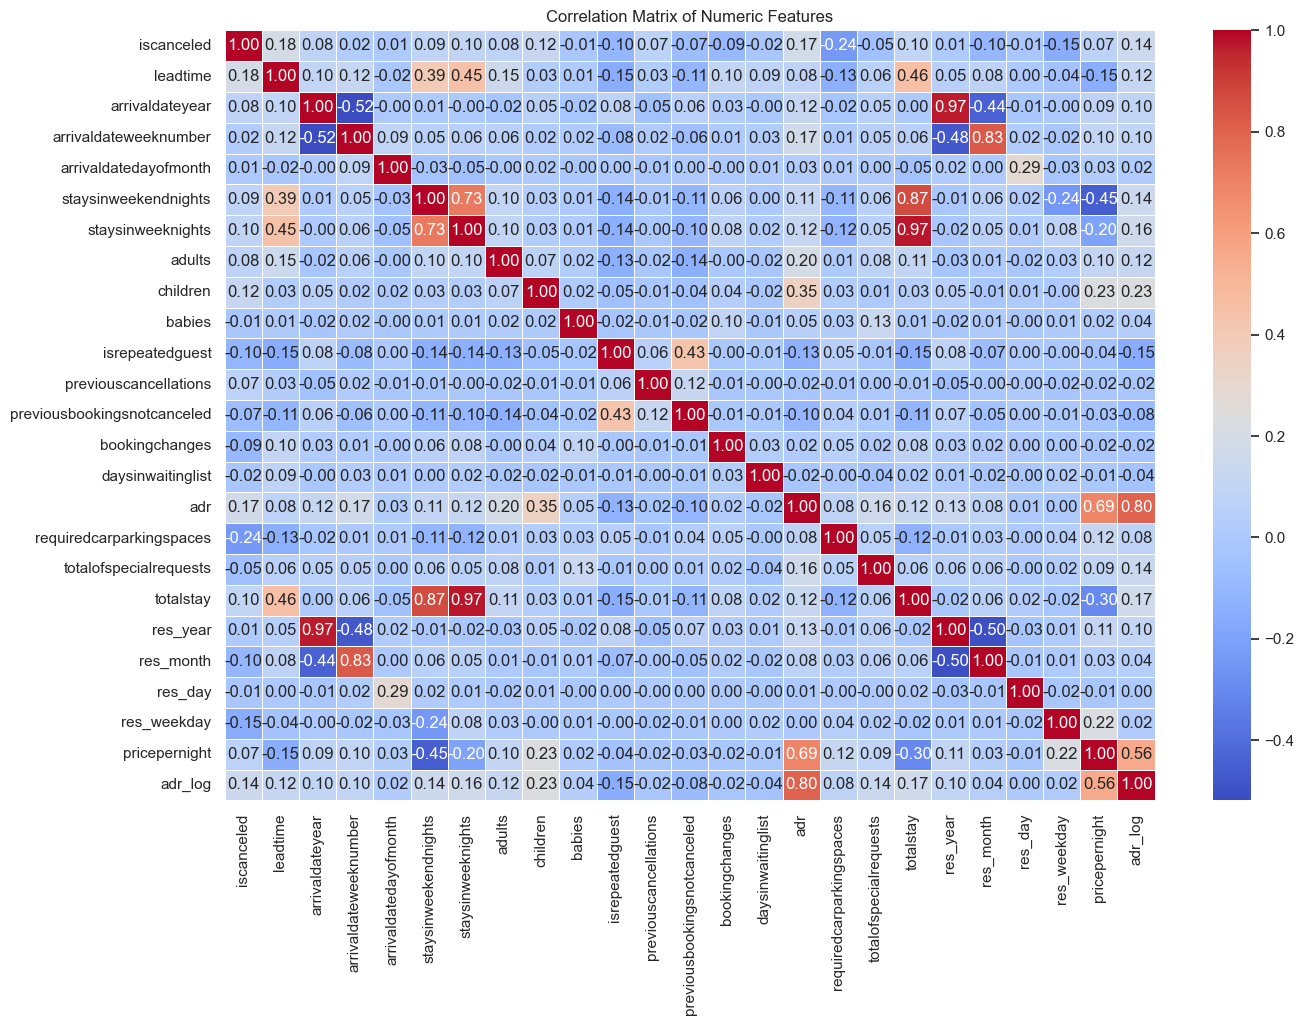

In [7]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### Findings from Correlation Analysis:
- **Lead Time** tends to have a positive correlation with cancellations.
- **Total Special Requests** usually shows a negative correlation (more requests often imply higher intent to stay).
- **Required Car Parking Spaces** is also often negatively correlated with cancellations.

## 3. Analyze ADR vs Cancellation Rate

Analysis of how the Average Daily Rate affects the likelihood of cancellation.

C:\Users\NEW\AppData\Local\Temp\ipykernel_13300\1983188412.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='iscanceled', y='adr', data=df, palette='Set2')


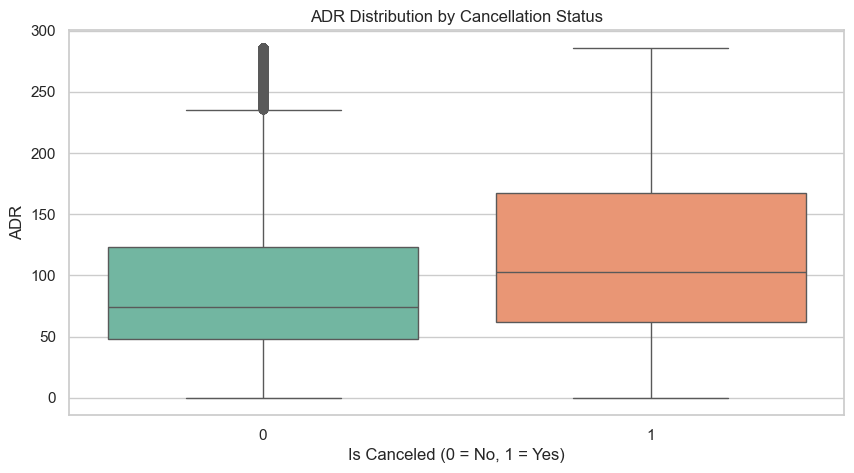

In [8]:
# Univariate analysis of ADR
plt.figure(figsize=(10, 5))
sns.boxplot(x='iscanceled', y='adr', data=df, palette='Set2')
plt.title('ADR Distribution by Cancellation Status')
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('ADR')
plt.show()

C:\Users\NEW\AppData\Local\Temp\ipykernel_13300\2706461611.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='adr_bin', y='iscanceled', data=adr_cancel_rate, palette='viridis')


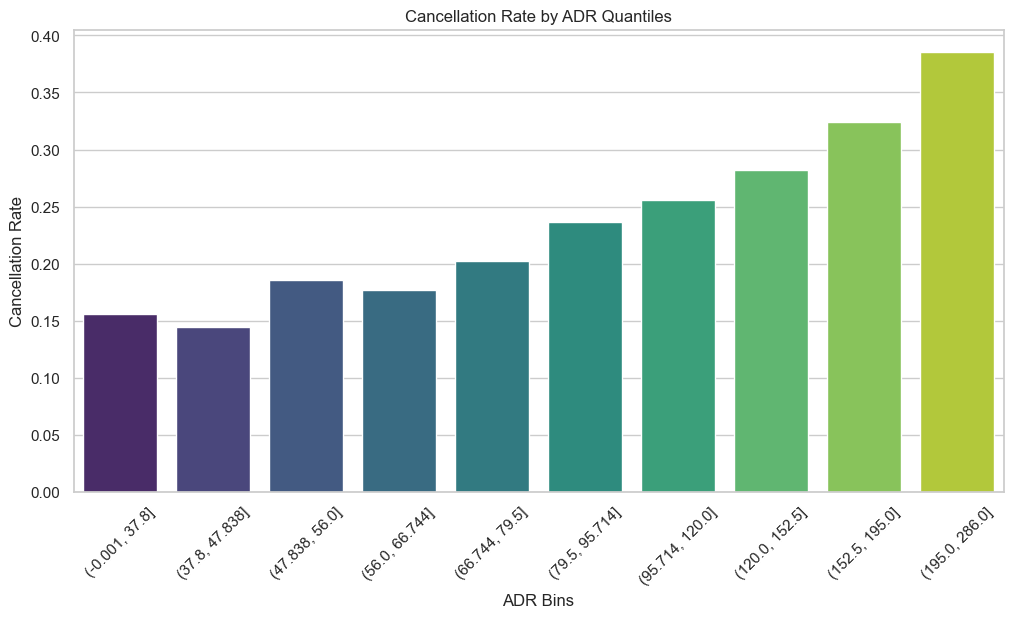

In [9]:
# Bivariate Analysis: ADR Binned vs Cancellation Rate
df['adr_bin'] = pd.qcut(df['adr'], q=10, duplicates='drop')
adr_cancel_rate = df.groupby('adr_bin')['iscanceled'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='adr_bin', y='iscanceled', data=adr_cancel_rate, palette='viridis')
plt.xticks(rotation=45)
plt.title('Cancellation Rate by ADR Quantiles')
plt.ylabel('Cancellation Rate')
plt.xlabel('ADR Bins')
plt.show()

### Summary of Findings:
- **ADR Impact**: Higher ADRs generally show a trend towards higher cancellation rates, suggesting that more expensive bookings are more prone to cancellations.
- **Lead Time**: Bookings made far in advance have a higher probability of being cancelled.
- **Special Requests**: Customers who make more special requests are significantly less likely to cancel their reservations.